In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

In [ ]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/"

names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num", "idk"]
df = pd.read_table(data_dir + 'cleve.mod', sep = r'\s+', names=names)
# df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,idk
0,63.0,male,angina,145.0,233.0,true,hyp,150.0,fal,2.3,down,0.0,fix,buff,H
1,67.0,male,asympt,160.0,286.0,fal,hyp,108.0,true,1.5,flat,3.0,norm,sick,S2
2,67.0,male,asympt,120.0,229.0,fal,hyp,129.0,true,2.6,flat,2.0,rev,sick,S1
3,37.0,male,notang,130.0,250.0,fal,norm,187.0,fal,3.5,down,0.0,norm,buff,H
4,41.0,fem,abnang,130.0,204.0,fal,hyp,172.0,fal,1.4,up,0.0,norm,buff,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,48.0,male,notang,124.0,255.0,true,norm,175.0,fal,0.0,up,2.0,norm,buff,H
299,57.0,male,asympt,132.0,207.0,fal,norm,168.0,true,0.0,up,0.0,rev,buff,H
300,49.0,male,notang,118.0,149.0,fal,hyp,126.0,fal,0.8,up,3.0,norm,sick,S1
301,74.0,fem,abnang,120.0,269.0,fal,hyp,121.0,true,0.2,up,1.0,norm,buff,H


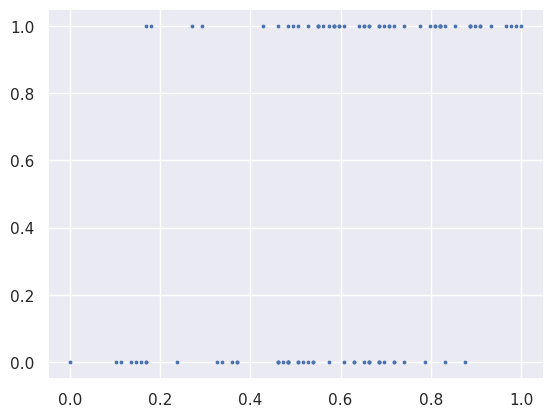

In [77]:
# attempt to predict G3 (end of semester grades) with something
train_df = df[["thalach", "num"]].iloc[0:100, :]
train_df.dropna(axis=0, how="any")
X = train_df["thalach"]
y = np.where(train_df["num"] == "buff", 1.0, 0.0) # true if healthy, false if sick
# colors = np.where(df["G3"] >= 8, "Blue", "red")
# plt.scatter(X, y, s=3)

# also clamp data
min_x, max_x = min(X), max(X)
x_len = max_x - min_x
X = (X - min_x) / x_len
plt.scatter(X, y, s=3)

In [78]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

In [79]:
class LogisticNeuron():
    def __init__(self, _activation_function):
        self.activation_function = _activation_function

    def train(self, X, y, eta = 0.01, epochs = 100):
        self.weight = np.random.rand()
        self.bias = np.random.rand()
        self.dim = X.shape[0]
        errors = np.empty(epochs)
        for epoch in range(epochs):
            y_hats = np.empty(self.dim)
            for i in range(self.dim):
                y_hats[i] = self.feed_forward(X[i])
            for i in range(self.dim):
                self.weight += -eta * (y_hats[i] - y[i]) * X[i]
                self.bias += -eta * (y_hats[i] - y[i])
            errors[epoch] = self.cost(y, y_hats)
        return errors
    
    def cost(self, y, y_hat):
        cost = 0.0
        for i in range(self.dim):
            cost += -y[i] * np.log(y_hat[i]) - (1.0 - y[i]) * np.log(1.0 - y_hat[i])
        return cost

    def feed_forward(self, x):
        return self.activation_function(self.weight * x + self.bias)
        

In [95]:
neuron = LogisticNeuron(sigmoid)
neuron.train(X, y, eta = 0.01, epochs = 10000)

array([72.12423515, 69.82333857, 68.62098705, ..., 59.20316265,
       59.20316265, 59.20316265], shape=(10000,))

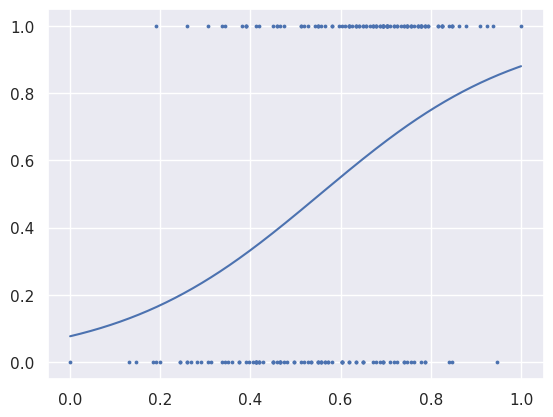

In [96]:
# now test against testing data
test_df = df[["thalach", "num"]].iloc[100:, :]
test_df.dropna(axis=0, how="any")
X_test = test_df["thalach"]
y_test = np.where(test_df["num"] == "buff", 1.0, 0.0) # true if healthy, false if sick

min_x, max_x = min(X_test), max(X_test)
x_len = max_x - min_x
X_test = (X_test - min_x) / x_len
plt.scatter(X_test, y_test, s=3)

t = np.linspace(0, 1, 1000)
t_y = [neuron.feed_forward(x) for x in t]
plt.plot(t, t_y)
plt.show()

In [97]:
test_values = [round(neuron.feed_forward(x)) for x in X_test]
exact_values = [int(y) for y in y_test]

test_error = sum(not exact_values[i]^test_values[i] for i in range(test_df.shape[0]))
print(test_error / test_df.shape[0])

0.6896551724137931
